In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pyro
import pyro.distributions as dist
from pyro import poutine
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
from dmm_nested import NestedDMM
from utils import log_returns, rogers_satchell_rv, realized_semivariance, yoy_log_change

c:\Users\mikah\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
spy = pd.read_csv('data/spy_ohlcv.csv', index_col=0, parse_dates=True, skiprows=[1, 2])

_icsa_raw = pd.read_csv('data/fred_icsa.csv', index_col=0, parse_dates=True).squeeze()

pool = {
    'ret':     log_returns(spy['Close']),
    'rv':      np.log(rogers_satchell_rv(spy).clip(lower=1e-8)),   # log-RV: real-valued, StudentT emission
    'rsv_down': realized_semivariance(log_returns(spy['Close']), window=5).clip(lower=1e-8),
    'T10Y3M':  pd.read_csv('data/fred_t10y3m.csv',  index_col=0, parse_dates=True).squeeze(),
    'BAA10Y':  pd.read_csv('data/fred_baa10y.csv',  index_col=0, parse_dates=True).squeeze(),
    'DGS2':    pd.read_csv('data/fred_dgs2.csv',    index_col=0, parse_dates=True).squeeze(),
    'ICSA':    yoy_log_change(_icsa_raw, periods=52),
    'CPI':     pd.read_csv('data/fred_cpi.csv',     index_col=0, parse_dates=True).squeeze(),
    'UMCSENT': pd.read_csv('data/fred_umcsent.csv', index_col=0, parse_dates=True).squeeze(),
}

for name, s in pool.items():
    valid = s.dropna()
    print(f"  {name:<8} {valid.index[0].date()} → {valid.index[-1].date()}  ({len(valid)} rows)")

  ret      1993-02-01 → 2026-05-15  (8380 rows)
  rv       1993-01-29 → 2026-05-15  (8381 rows)
  rsv_down 1993-02-01 → 2026-05-15  (8380 rows)
  T10Y3M   1982-01-04 → 2026-05-15  (11095 rows)
  BAA10Y   1986-01-02 → 2026-05-14  (10092 rows)
  DGS2     1976-06-01 → 2026-05-14  (12485 rows)
  ICSA     1968-01-06 → 2026-05-09  (3045 rows)
  CPI      1947-01-01 → 2026-04-01  (951 rows)
  UMCSENT  1952-11-01 → 2026-03-01  (671 rows)


In [3]:
# ── FEATURE CONFIG ─────────────────────────────────────────────────────────
FAST_FEATURES = [
    ('ret',      'studentt'),
    ('rv',       'studentt'),   # log-RV, StudentT emission; separate df/mu/sigma from ret
    ('rsv_down', 'lognormal'),  # 5-day downside semivariance: asymmetric vol signal
]
SLOW_FEATURES = [
    ('T10Y3M',  'normal'),
    ('BAA10Y',  'normal'),
    ('DGS2',    'normal'),
    ('ICSA',    'normal'),      # YoY log-change in initial claims: stationary labor stress signal
    ('CPI',     'normal'),
    ('UMCSENT', 'normal'),
]
K = 20   # trading days per slow period (≈ 1 month)
# ────────────────────────────────────────────────────────────────────────────

fast_names = [f[0] for f in FAST_FEATURES]
slow_names = [f[0] for f in SLOW_FEATURES]

n_st_fast  = sum(1 for _, t in FAST_FEATURES if t == 'studentt')
n_ln_fast  = sum(1 for _, t in FAST_FEATURES if t == 'lognormal')
n_n_fast   = sum(1 for _, t in FAST_FEATURES if t == 'normal')
n_st_slow  = sum(1 for _, t in SLOW_FEATURES if t == 'studentt')
n_ln_slow  = sum(1 for _, t in SLOW_FEATURES if t == 'lognormal')
n_n_slow   = sum(1 for _, t in SLOW_FEATURES if t == 'normal')
n_fast     = len(FAST_FEATURES)
n_slow     = len(SLOW_FEATURES)

print(f"Fast  ({n_fast}): studentt={n_st_fast}  lognormal={n_ln_fast}  normal={n_n_fast}")
print(f"Slow  ({n_slow}): studentt={n_st_slow}  lognormal={n_ln_slow}  normal={n_n_slow}")
print(f"K = {K} days per slow period")

Fast  (3): studentt=2  lognormal=1  normal=0
Slow  (6): studentt=0  lognormal=0  normal=6
K = 20 days per slow period


In [4]:
# Align fast features to the daily trading calendar derived from returns.
# Align slow features to end-of-period dates (every K-th trading day).
trading_days = pool['ret'].dropna().index

fast_df = pd.concat(
    [pool[name].reindex(trading_days, method='ffill').rename(name) for name in fast_names],
    axis=1
).dropna().sort_index()

# End-of-period dates: indices K-1, 2K-1, 3K-1, ...
slow_period_idx  = np.arange(K - 1, len(fast_df), K)
slow_period_dates = fast_df.index[slow_period_idx]

slow_df = pd.concat(
    [pool[name].reindex(slow_period_dates, method='ffill').rename(name) for name in slow_names],
    axis=1
).dropna().sort_index()

# Trim fast_df so T_fast = T_slow * K exactly
T_slow_total = len(slow_df)
T_fast_total = T_slow_total * K
fast_df = fast_df.iloc[:T_fast_total]

print(f"Fast: {fast_df.index[0].date()} \u2192 {fast_df.index[-1].date()}  ({len(fast_df)} days)")
print(f"Slow: {slow_df.index[0].date()} \u2192 {slow_df.index[-1].date()}  ({len(slow_df)} periods)")
fast_df.describe()

Fast: 1993-02-01 → 2026-05-15  (8380 days)
Slow: 1993-03-01 → 2026-05-15  (419 periods)


,ret,rv,rsv_down
count,8380.000000,8380.000000,8.380000e+03
mean,0.000408,-5.149311,7.004178e-05
std,0.011714,1.213811,2.085773e-04
min,-0.115887,-18.420681,1.000000e-08
25%,-0.004325,-5.508027,3.319750e-06
50%,0.000682,-5.085721,1.777029e-05
75%,0.005932,-4.663635,6.607854e-05
max,0.135577,-2.436528,5.248715e-03


In [5]:
n_train_slow = 225   # ≈ 4500 trading days (same as dmm_diagnostics)
n_test_slow  = 150   # ≈ 3000 trading days

n_train_fast = n_train_slow * K
n_test_fast  = n_test_slow  * K

fast_train_raw = fast_df.iloc[:n_train_fast]
fast_test_raw  = fast_df.iloc[n_train_fast : n_train_fast + n_test_fast]
slow_train_raw = slow_df.iloc[:n_train_slow]
slow_test_raw  = slow_df.iloc[n_train_slow : n_train_slow + n_test_slow]

# Normalization params fit on training data only.
norm_params_fast = {}
for name, etype in FAST_FEATURES:
    if etype in ('studentt', 'normal'):
        norm_params_fast[name] = {'mean': fast_train_raw[name].mean(), 'std': fast_train_raw[name].std()}
    else:
        norm_params_fast[name] = {'mean': fast_train_raw[name].mean()}

norm_params_slow = {}
for name, etype in SLOW_FEATURES:
    if etype in ('studentt', 'normal'):
        norm_params_slow[name] = {'mean': slow_train_raw[name].mean(), 'std': slow_train_raw[name].std()}
    else:
        norm_params_slow[name] = {'mean': slow_train_raw[name].mean()}

def normalize_fast(df):
    out = df.copy()
    for name, etype in FAST_FEATURES:
        p = norm_params_fast[name]
        out[name] = (df[name] - p['mean']) / p['std'] if etype in ('studentt', 'normal') else df[name] / p['mean']
    return out

def normalize_slow(df):
    out = df.copy()
    for name, etype in SLOW_FEATURES:
        p = norm_params_slow[name]
        out[name] = (df[name] - p['mean']) / p['std'] if etype in ('studentt', 'normal') else df[name] / p['mean']
    return out

fast_train_norm = normalize_fast(fast_train_raw)
fast_test_norm  = normalize_fast(fast_test_raw)
slow_train_norm = normalize_slow(slow_train_raw)
slow_test_norm  = normalize_slow(slow_test_raw)

print(f"fast train: {len(fast_train_norm)}  ({fast_train_raw.index[0].date()} \u2192 {fast_train_raw.index[-1].date()})")
print(f"fast test:  {len(fast_test_norm)}  ({fast_test_raw.index[0].date()} \u2192 {fast_test_raw.index[-1].date()})")
print(f"slow train: {len(slow_train_norm)} periods")
print(f"slow test:  {len(slow_test_norm)} periods")

fast train: 4500  (1993-02-01 → 2010-12-09)
fast test:  3000  (2010-12-10 → 2022-11-09)
slow train: 225 periods
slow test:  150 periods


In [6]:
# Build batched training windows: each window = W slow steps + W*K fast steps.
W = 5   # slow steps per training window  (= 100 trading days ≈ 5 months)

fast_arr = fast_train_norm.values.astype(np.float32)   # (n_train_fast, n_fast)
slow_arr = slow_train_norm.values.astype(np.float32)   # (n_train_slow, n_slow)

n_windows    = n_train_slow // W
fast_windows = fast_arr[:n_windows * W * K].reshape(n_windows, W * K, n_fast)
slow_windows = slow_arr[:n_windows * W].reshape(n_windows, W, n_slow)

train_fast_t = torch.tensor(fast_windows)   # (n_windows, W*K, n_fast)
train_slow_t = torch.tensor(slow_windows)   # (n_windows, W,   n_slow)
print(f"Training tensors — fast: {tuple(train_fast_t.shape)}  slow: {tuple(train_slow_t.shape)}")

# Full single-sequence tensors for inference (batch=1, full length)
xf_train_seq = torch.tensor(fast_train_norm.values.astype(np.float32)).unsqueeze(0)  # (1, n_train_fast, n_fast)
xs_train_seq = torch.tensor(slow_train_norm.values.astype(np.float32)).unsqueeze(0)  # (1, n_train_slow, n_slow)
xf_test_seq  = torch.tensor(fast_test_norm.values.astype(np.float32)).unsqueeze(0)
xs_test_seq  = torch.tensor(slow_test_norm.values.astype(np.float32)).unsqueeze(0)
print(f"Inference tensors — fast train: {tuple(xf_train_seq.shape)}  slow train: {tuple(xs_train_seq.shape)}")

Training tensors — fast: (45, 100, 3)  slow: (45, 5, 6)
Inference tensors — fast train: (1, 4500, 3)  slow train: (1, 225, 6)


In [7]:
batch_size = 32
loader = DataLoader(TensorDataset(train_fast_t, train_slow_t), batch_size=batch_size, shuffle=True)
print(f"batches per epoch: {len(loader)}")

batches per epoch: 2


In [8]:
s_dim          = 4
f_dim          = 8
hidden_dim     = 64
rnn_slow_hidden = 32
rnn_fast_hidden = 64
rnn_num_layers  = 1

dmm = NestedDMM(
    n_st_fast=n_st_fast, n_ln_fast=n_ln_fast, n_n_fast=n_n_fast,
    n_st_slow=n_st_slow, n_ln_slow=n_ln_slow, n_n_slow=n_n_slow,
    s_dim=s_dim, f_dim=f_dim,
    hidden_dim=hidden_dim,
    rnn_fast_hidden=rnn_fast_hidden,
    rnn_slow_hidden=rnn_slow_hidden,
    rnn_num_layers=rnn_num_layers,
    K=K,
)
total_params = sum(p.numel() for p in dmm.parameters())
print(f"NestedDMM  |  total params: {total_params:,}")

NestedDMM  |  total params: 27,592


c:\Users\mikah\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


In [9]:
def elbo_terms(model, guide, x_fast, x_slow):
    """Decompose ELBO into its 4 terms for the nested DMM."""
    guide_trace = poutine.trace(guide).get_trace(x_fast, x_slow)
    model_trace = poutine.trace(poutine.replay(model, trace=guide_trace)).get_trace(x_fast, x_slow)
    guide_trace.compute_log_prob()
    model_trace.compute_log_prob()

    slow_recon = sum(
        site['log_prob_sum']
        for name, site in model_trace.nodes.items()
        if site['type'] == 'sample' and site['is_observed'] and name.startswith('x_slow')
    )
    fast_recon = sum(
        site['log_prob_sum']
        for name, site in model_trace.nodes.items()
        if site['type'] == 'sample' and site['is_observed'] and name.startswith('x_fast')
    )
    slow_kl = sum(
        guide_trace.nodes[name]['log_prob_sum'] - model_trace.nodes[name]['log_prob_sum']
        for name, site in guide_trace.nodes.items()
        if site['type'] == 'sample' and name.startswith('s_')
    )
    fast_kl = sum(
        guide_trace.nodes[name]['log_prob_sum'] - model_trace.nodes[name]['log_prob_sum']
        for name, site in guide_trace.nodes.items()
        if site['type'] == 'sample' and name.startswith('f_')
    )
    return slow_recon.item(), fast_recon.item(), slow_kl.item(), fast_kl.item()

In [10]:
pyro.clear_param_store()
optimizer = Adam({'lr': 1e-3})
svi = SVI(dmm.model, dmm.guide, optimizer, loss=Trace_ELBO())

# Grab a fixed diagnostic batch (first batch, no shuffle effect)
diag_fast, diag_slow = next(iter(
    DataLoader(TensorDataset(train_fast_t, train_slow_t), batch_size=64, shuffle=False)
))

num_epochs = 251
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_fast, batch_slow in loader:
        epoch_loss += svi.step(batch_fast, batch_slow)
    if epoch % 50 == 0:
        with torch.no_grad():
            sr, fr, sk, fk = elbo_terms(dmm.model, dmm.guide, diag_fast, diag_slow)
        print(
            f"epoch {epoch:4d}  "
            f"loss: {epoch_loss / len(loader):9.2f}  "
            f"recon_slow: {sr:9.2f}  recon_fast: {fr:9.2f}  "
            f"KL_slow: {sk:8.2f}  KL_fast: {fk:8.2f}"
        )

epoch    0  loss:  29300.78  recon_slow:  -2356.55  recon_fast: -47085.20  KL_slow:   114.63  KL_fast:  5916.83
epoch   50  loss:   7016.77  recon_slow:  -1850.86  recon_fast: -11522.22  KL_slow:    31.82  KL_fast:   653.24
epoch  100  loss:   6171.39  recon_slow:  -1377.98  recon_fast:  -9882.19  KL_slow:   116.46  KL_fast:   900.79
epoch  150  loss:   5430.76  recon_slow:  -1082.66  recon_fast:  -8052.30  KL_slow:   246.27  KL_fast:  1313.31
epoch  200  loss:   5079.62  recon_slow:   -859.71  recon_fast:  -7667.31  KL_slow:   303.54  KL_fast:  1360.95
epoch  250  loss:   4892.81  recon_slow:   -722.77  recon_fast:  -7393.39  KL_slow:   341.64  KL_fast:  1341.04


In [11]:
# Causal inference: forward RNN, single pass, no rolling windows, no lag.
# State at tau uses x_slow[0:tau+1]; state at t uses x_fast[0:t+1].
# Outputs cover the full sequence length.
with torch.no_grad():
    s_means_tr, _, f_means_tr, _ = dmm.infer(xf_train_seq, xs_train_seq)
    s_means_te, _, f_means_te, _ = dmm.infer(xf_test_seq,  xs_test_seq)

s_train = s_means_tr.squeeze(0).numpy()   # (n_train_slow, s_dim)
f_train = f_means_tr.squeeze(0).numpy()   # (n_train_fast, f_dim)
s_test  = s_means_te.squeeze(0).numpy()   # (n_test_slow,  s_dim)
f_test  = f_means_te.squeeze(0).numpy()   # (n_test_fast,  f_dim)

slow_dates_train = fast_train_raw.index[K - 1 :: K][:n_train_slow]
slow_dates_test  = fast_test_raw.index[K - 1 :: K][:n_test_slow]
fast_dates_train = fast_train_raw.index
fast_dates_test  = fast_test_raw.index

print(f"s_train: {s_train.shape}  {slow_dates_train[0].date()} → {slow_dates_train[-1].date()}")
print(f"f_train: {f_train.shape}  {fast_dates_train[0].date()} → {fast_dates_train[-1].date()}")
print(f"s_test:  {s_test.shape}   {slow_dates_test[0].date()} → {slow_dates_test[-1].date()}")
print(f"f_test:  {f_test.shape}   {fast_dates_test[0].date()} → {fast_dates_test[-1].date()}")

s_train: (225, 4)  1993-03-01 → 2010-12-09
f_train: (4500, 8)  1993-02-01 → 2010-12-09
s_test:  (150, 4)   2011-01-07 → 2022-11-09
f_test:  (3000, 8)   2010-12-10 → 2022-11-09


In [18]:
# ── PCA setup (shared by both chart cells) ─────────────────────────────────
REGIMES = [
    (pd.Timestamp('2000-01-01'), 'royalblue',    'Pre-dot-com (< 2000)'),
    (pd.Timestamp('2003-01-01'), 'firebrick',    'Dot-com crash (2000–2003)'),
    (pd.Timestamp('2008-01-01'), 'steelblue',    'Mid-cycle (2003–2008)'),
    (pd.Timestamp('2010-01-01'), 'crimson',      'GFC (2008–2010)'),
    (pd.Timestamp('2020-01-01'), 'seagreen',     'Recovery (2010–2020)'),
    (pd.Timestamp('2021-06-01'), 'darkorange',   'COVID (2020–mid-2021)'),
    (None,                       'mediumpurple', 'Post-COVID (≥ mid-2021)'),
]

def assign_colors(dates):
    colors = []
    for d in dates:
        for cutoff, color, _ in REGIMES:
            if cutoff is None or d < cutoff:
                colors.append(color)
                break
    return colors

def axis_limits(pc_a, pc_b, pad=0.06):
    combined = np.vstack([pc_a, pc_b])
    xr = combined[:, 0].max() - combined[:, 0].min()
    yr = combined[:, 1].max() - combined[:, 1].min()
    return (
        (combined[:, 0].min() - pad * xr, combined[:, 0].max() + pad * xr),
        (combined[:, 1].min() - pad * yr, combined[:, 1].max() + pad * yr),
    )

pca_s = PCA(n_components=2)
pca_s.fit(s_train)
pc_s_tr = pca_s.transform(s_train)
pc_s_te = pca_s.transform(s_test)

pca_f = PCA(n_components=2)
pca_f.fit(f_train)
pc_f_tr = pca_f.transform(f_train)
pc_f_te = pca_f.transform(f_test)

c_s_tr = assign_colors(slow_dates_train)
c_s_te = assign_colors(slow_dates_test)
c_f_tr = assign_colors(fast_dates_train)
c_f_te = assign_colors(fast_dates_test)

var_s = pca_s.explained_variance_ratio_
var_f = pca_f.explained_variance_ratio_

xlim_s, ylim_s = axis_limits(pc_s_tr, pc_s_te)
xlim_f, ylim_f = axis_limits(pc_f_tr, pc_f_te)

legend_handles = [mpatches.Patch(color=c, label=l) for _, c, l in REGIMES]
print('PCA ready.')

PCA ready.


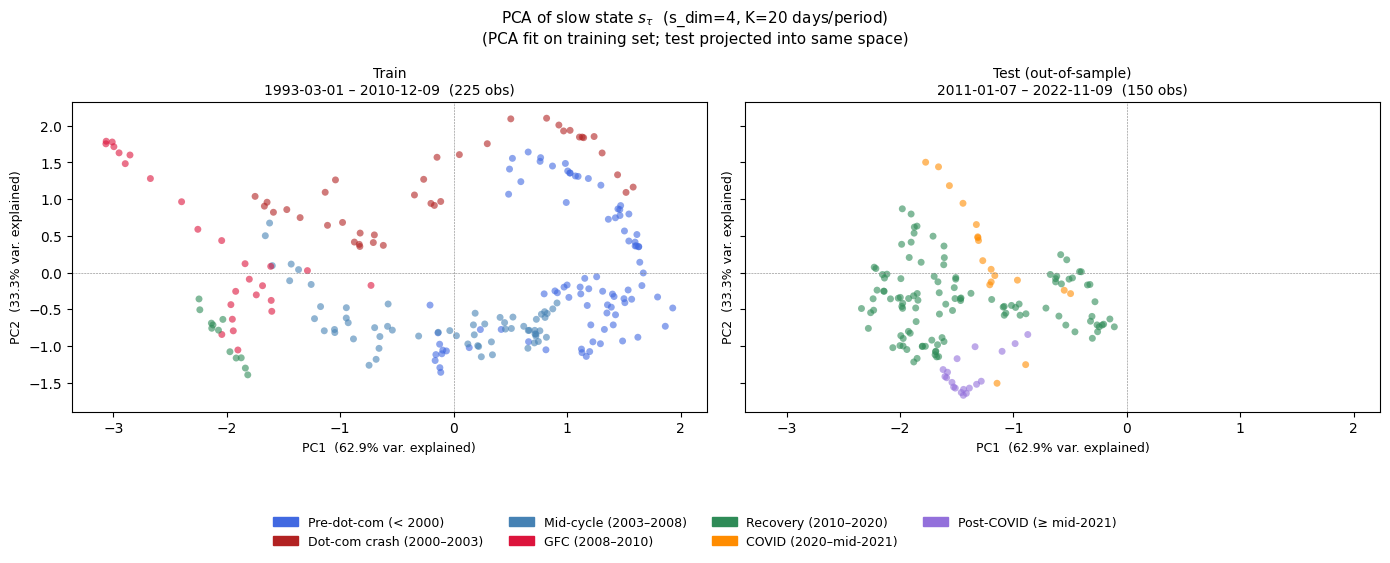

In [19]:
# ── Slow states  s_tau ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

panels_s = [
    (axes[0], pc_s_tr, c_s_tr,
     f'Train\n{slow_dates_train[0].date()} – {slow_dates_train[-1].date()}  ({len(s_train)} obs)'),
    (axes[1], pc_s_te, c_s_te,
     f'Test (out-of-sample)\n{slow_dates_test[0].date()} – {slow_dates_test[-1].date()}  ({len(s_test)} obs)'),
]

for ax, pc, colors, title in panels_s:
    ax.scatter(pc[:, 0], pc[:, 1], c=colors, alpha=0.6, s=25, linewidths=0)
    ax.set_xlim(xlim_s)
    ax.set_ylim(ylim_s)
    ax.set_xlabel(f'PC1  ({var_s[0]:.1%} var. explained)', fontsize=9)
    ax.set_ylabel(f'PC2  ({var_s[1]:.1%} var. explained)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=9)
fig.suptitle(
    f'PCA of slow state $s_{{\\tau}}$  (s_dim={s_dim}, K={K} days/period)\n'
    '(PCA fit on training set; test projected into same space)',
    fontsize=11,
)
plt.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])
plt.savefig('pca_slow.png', dpi=150, bbox_inches='tight')
plt.show()

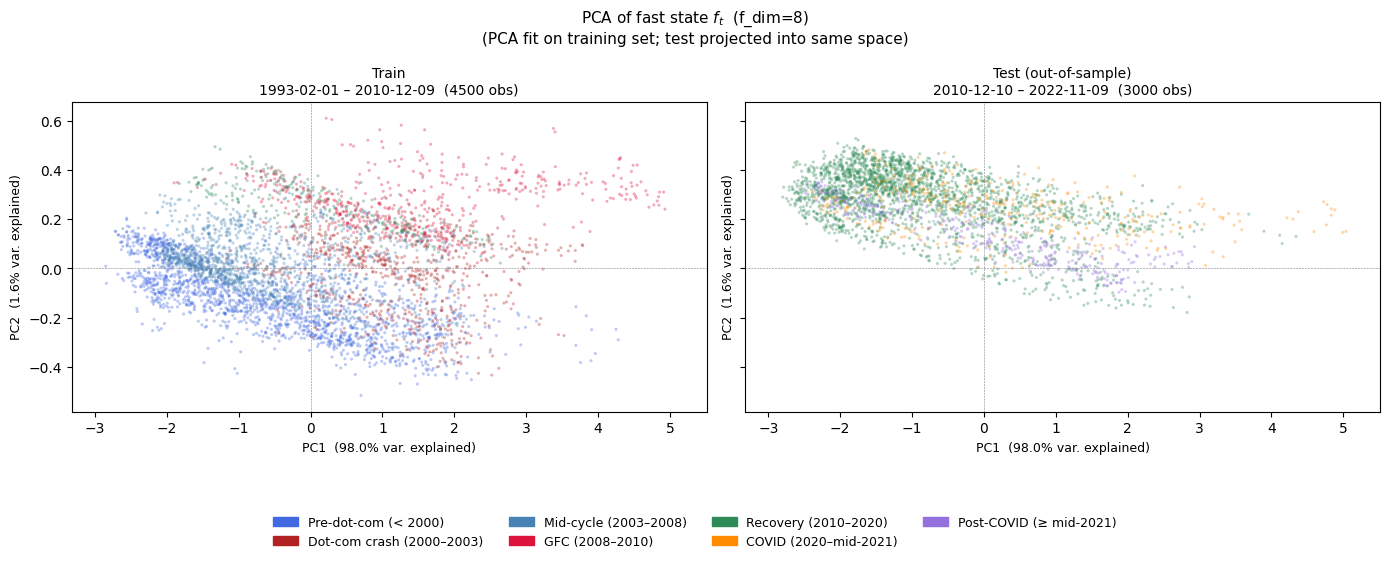

In [20]:
# ── Fast states  f_t ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

panels_f = [
    (axes[0], pc_f_tr, c_f_tr,
     f'Train\n{fast_dates_train[0].date()} – {fast_dates_train[-1].date()}  ({len(f_train)} obs)'),
    (axes[1], pc_f_te, c_f_te,
     f'Test (out-of-sample)\n{fast_dates_test[0].date()} – {fast_dates_test[-1].date()}  ({len(f_test)} obs)'),
]

for ax, pc, colors, title in panels_f:
    ax.scatter(pc[:, 0], pc[:, 1], c=colors, alpha=0.35, s=5, linewidths=0)
    ax.set_xlim(xlim_f)
    ax.set_ylim(ylim_f)
    ax.set_xlabel(f'PC1  ({var_f[0]:.1%} var. explained)', fontsize=9)
    ax.set_ylabel(f'PC2  ({var_f[1]:.1%} var. explained)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=9)
fig.suptitle(
    f'PCA of fast state $f_{{t}}$  (f_dim={f_dim})\n'
    '(PCA fit on training set; test projected into same space)',
    fontsize=11,
)
plt.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])
plt.savefig('pca_fast.png', dpi=150, bbox_inches='tight')
plt.show()

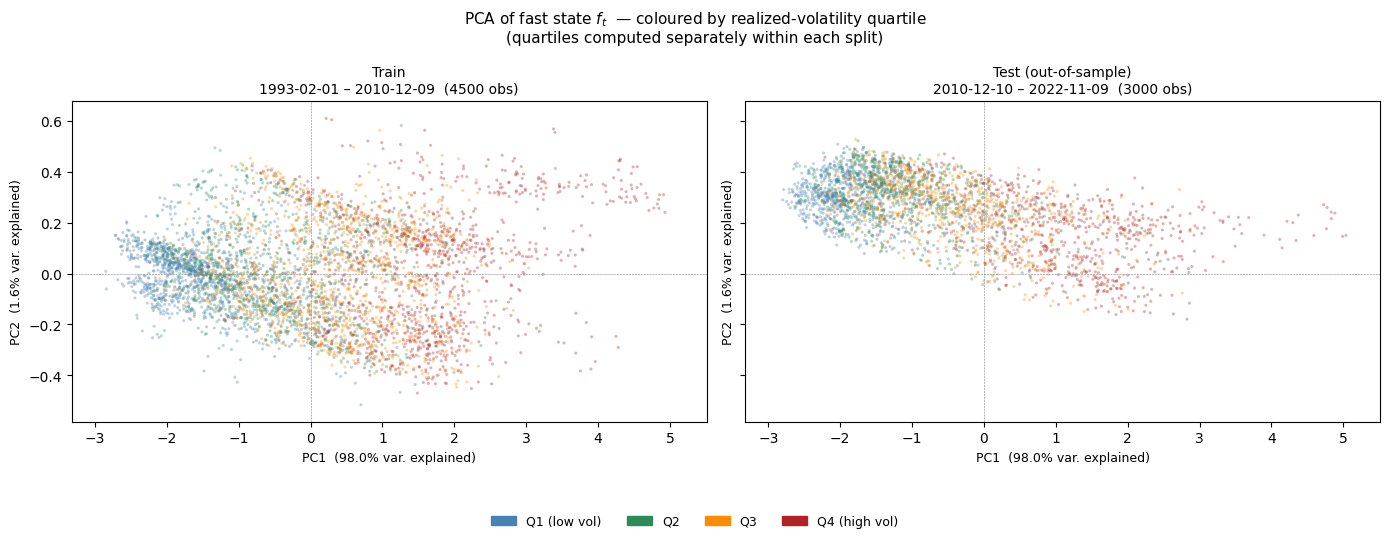

In [15]:
# ── Fast states: RV-quartile colouring ────────────────────────────────────
# Quartile boundaries computed separately within each split so the scale
# reflects the local vol distribution of that period, not a shared one.

rv_tr = pool['rv'].reindex(fast_dates_train, method='ffill').values
rv_te = pool['rv'].reindex(fast_dates_test,  method='ffill').values

Q_COLORS = ['steelblue', 'seagreen', 'darkorange', 'firebrick']
Q_LABELS = ['Q1 (low vol)', 'Q2', 'Q3', 'Q4 (high vol)']

def rv_quartile_colors(rv_vals):
    bounds = np.quantile(rv_vals, [0.25, 0.50, 0.75])
    idx    = np.digitize(rv_vals, bounds)   # 0, 1, 2, 3
    return [Q_COLORS[i] for i in idx]

c_rv_tr = rv_quartile_colors(rv_tr)
c_rv_te = rv_quartile_colors(rv_te)

q_handles = [mpatches.Patch(color=c, label=l) for c, l in zip(Q_COLORS, Q_LABELS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

panels_rv = [
    (axes[0], pc_f_tr, c_rv_tr,
     f'Train\n{fast_dates_train[0].date()} – {fast_dates_train[-1].date()}  ({len(f_train)} obs)'),
    (axes[1], pc_f_te, c_rv_te,
     f'Test (out-of-sample)\n{fast_dates_test[0].date()} – {fast_dates_test[-1].date()}  ({len(f_test)} obs)'),
]

for ax, pc, colors, title in panels_rv:
    ax.scatter(pc[:, 0], pc[:, 1], c=colors, alpha=0.35, s=5, linewidths=0)
    ax.set_xlim(xlim_f)
    ax.set_ylim(ylim_f)
    ax.set_xlabel(f'PC1  ({var_f[0]:.1%} var. explained)', fontsize=9)
    ax.set_ylabel(f'PC2  ({var_f[1]:.1%} var. explained)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

fig.legend(handles=q_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=9)
fig.suptitle(
    f'PCA of fast state $f_{{t}}$  — coloured by realized-volatility quartile\n'
    '(quartiles computed separately within each split)',
    fontsize=11,
)
plt.tight_layout(rect=[0.0, 0.04, 1.0, 1.0])
plt.savefig('pca_fast_rv_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

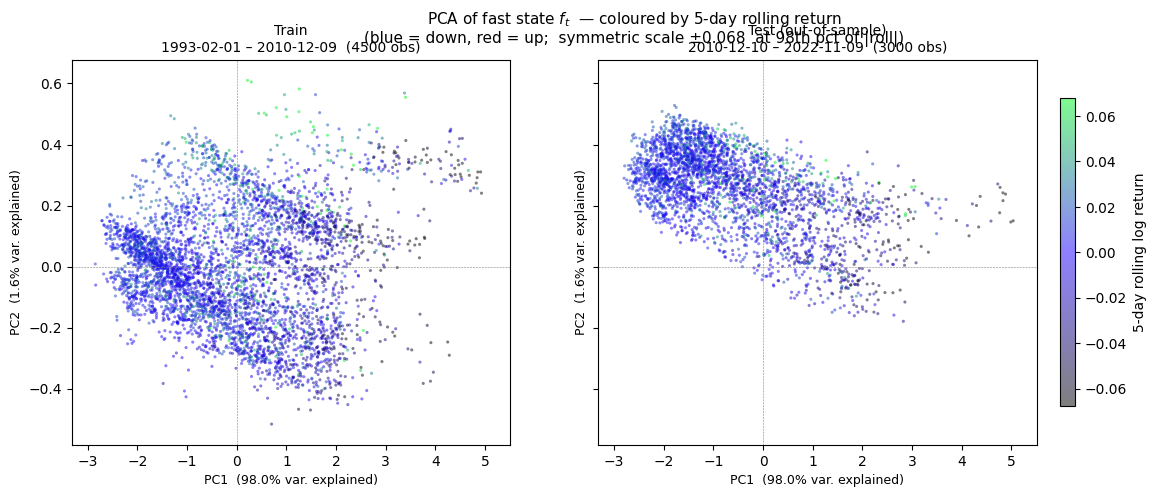

In [16]:
# ── Fast states: 5-day rolling return (temperature colouring) ─────────────
# Custom diverging colormap: deep blue → slate gray → deep red.
# Avoids the near-white midpoint of RdBu_r that bleeds into the background.

from matplotlib.colors import LinearSegmentedColormap

cmap_ret = LinearSegmentedColormap.from_list(
    'ret_div', ["#000000", "#1E00FF", "#00F621"]
)   # Material Blue-800 → Blue-Grey-600 → Red-800

ret_tr = pool['ret'].reindex(fast_dates_train)
ret_te = pool['ret'].reindex(fast_dates_test)

roll_tr = ret_tr.rolling(5, min_periods=1).sum().values
roll_te = ret_te.rolling(5, min_periods=1).sum().values

vmax = max(
    np.nanpercentile(np.abs(roll_tr), 98),
    np.nanpercentile(np.abs(roll_te), 98),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

panels_roll = [
    (axes[0], pc_f_tr, roll_tr,
     f'Train\n{fast_dates_train[0].date()} – {fast_dates_train[-1].date()}  ({len(f_train)} obs)'),
    (axes[1], pc_f_te, roll_te,
     f'Test (out-of-sample)\n{fast_dates_test[0].date()} – {fast_dates_test[-1].date()}  ({len(f_test)} obs)'),
]

for ax, pc, roll, title in panels_roll:
    sc = ax.scatter(pc[:, 0], pc[:, 1], c=roll, cmap=cmap_ret,
                    vmin=-vmax, vmax=vmax, alpha=0.5, s=5, linewidths=0)
    ax.set_xlim(xlim_f)
    ax.set_ylim(ylim_f)
    ax.set_xlabel(f'PC1  ({var_f[0]:.1%} var. explained)', fontsize=9)
    ax.set_ylabel(f'PC2  ({var_f[1]:.1%} var. explained)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4, linestyle='--')

fig.colorbar(sc, ax=axes.tolist(), orientation='vertical',
             shrink=0.8, pad=0.02, label='5-day rolling log return')
fig.suptitle(
    f'PCA of fast state $f_{{t}}$  — coloured by 5-day rolling return\n'
    f'(blue = down, red = up;  symmetric scale ±{vmax:.3f}  at 98th pct of |roll|)',
    fontsize=11,
)
plt.savefig('pca_fast_rolling_ret.png', dpi=150, bbox_inches='tight')
plt.show()

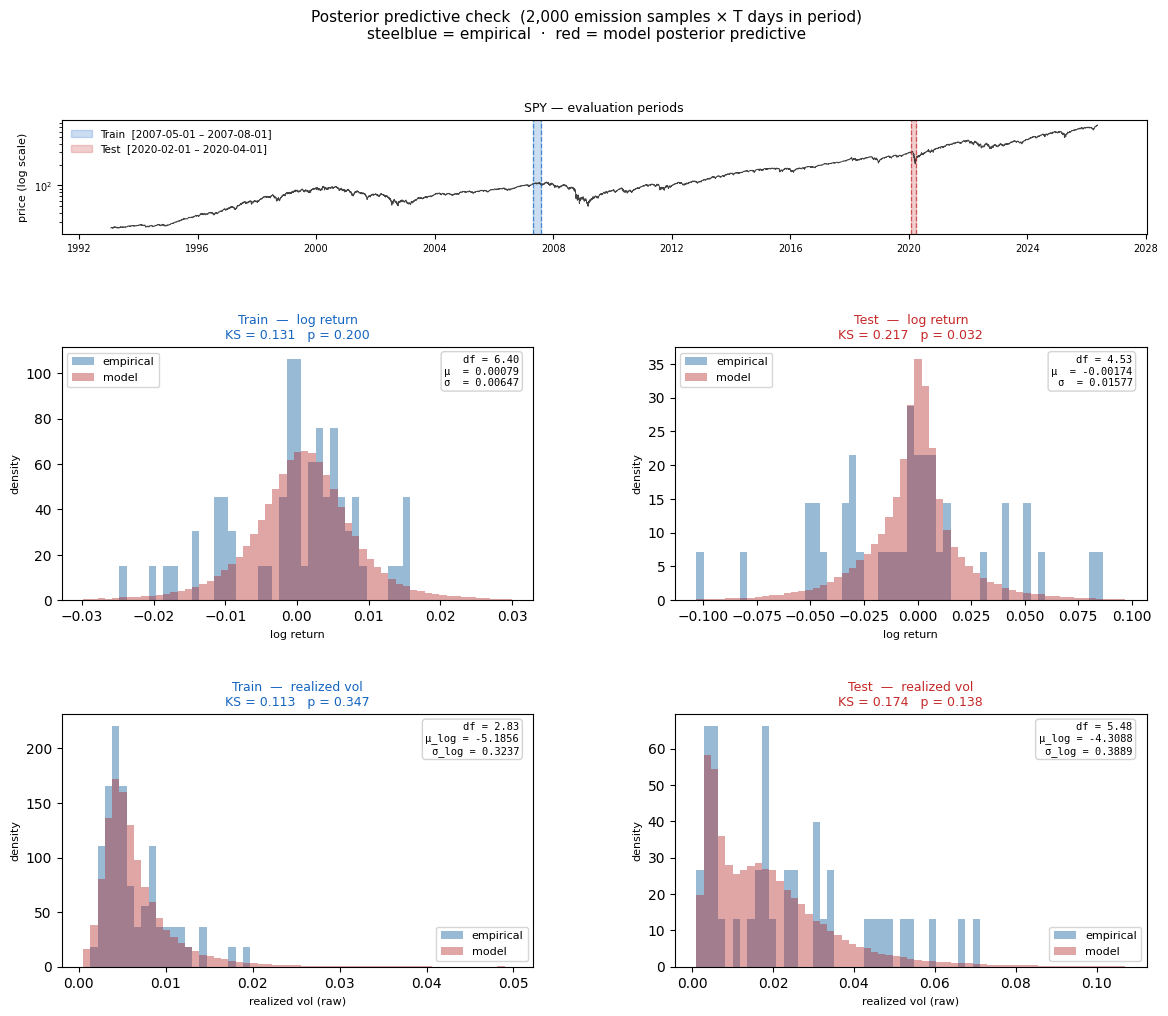

In [21]:
# ── Posterior predictive check: log-return and realized vol ────────────────
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import ks_2samp

N_SAMPLES = 2000

# Period colours: matched between SPY shading and subplot titles
PERIOD_COLORS = {
    'Train': '#1565C0',
    'Test':  '#C62828',
}

PERIODS = {
    'Train': ('2007-05-01', '2007-08-01', fast_dates_train, f_train),
    'Test':  ('2020-02-01', '2020-04-01', fast_dates_test,  f_test),
}

def emission_samples(dmm, f_states, n_samples):
    """Sample from fast emission distributions; returns denormalized values and period-avg params.

    StudentT features: [ret (idx 0), log(rv) (idx 1)].  rv samples are exponentiated to raw space.
    """
    with torch.no_grad():
        f_t = torch.tensor(f_states, dtype=torch.float32)
        df, st_mu, st_sigma, _, _, _, _ = dmm.fast_emitter(f_t)
        # sample both StudentT features together: (n_samples, T, 2)
        st_s = dist.StudentT(df, st_mu, st_sigma).sample([n_samples])

    p_ret = norm_params_fast['ret']
    p_rv  = norm_params_fast['rv']   # mean/std of log(rv)

    # ret (idx 0): z-score inverse
    ret_out = st_s[..., 0].flatten().numpy() * p_ret['std'] + p_ret['mean']
    # rv  (idx 1): z-score inverse → log(rv) → exp → raw rv
    rv_out  = np.exp(st_s[..., 1].flatten().numpy() * p_rv['std'] + p_rv['mean'])

    params = {
        'df_ret':    float(df[:, 0].mean()),
        'ret_mu':    float(st_mu[:, 0].mean()) * p_ret['std'] + p_ret['mean'],
        'ret_sigma': float(st_sigma[:, 0].mean()) * p_ret['std'],
        'df_rv':     float(df[:, 1].mean()),
        'rv_mu':     float(st_mu[:, 1].mean()) * p_rv['std'] + p_rv['mean'],   # in log(rv) space
        'rv_sigma':  float(st_sigma[:, 1].mean()) * p_rv['std'],
    }
    return ret_out, rv_out, params

# ── Figure layout: SPY strip on top, 2×2 histograms below ──
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[0.9, 2, 2], hspace=0.55, wspace=0.3)

ax_spy   = fig.add_subplot(gs[0, :])
ppc_axes = [[fig.add_subplot(gs[r + 1, c]) for c in range(2)] for r in range(2)]

# ── SPY price with period shading ──
spy_close = spy['Close'].dropna()
ax_spy.plot(spy_close.index, spy_close.values, color='#222222', linewidth=0.7, alpha=0.85)
ax_spy.set_yscale('log')

for label, (t0, t1, *_) in PERIODS.items():
    color = PERIOD_COLORS[label]
    ax_spy.axvspan(pd.Timestamp(t0), pd.Timestamp(t1),
                   alpha=0.22, color=color, label=f'{label}  [{t0} – {t1}]')
    ax_spy.axvline(pd.Timestamp(t0), color=color, linewidth=0.9, linestyle='--', alpha=0.7)
    ax_spy.axvline(pd.Timestamp(t1), color=color, linewidth=0.9, linestyle='--', alpha=0.7)

ax_spy.legend(loc='upper left', fontsize=7.5, frameon=False)
ax_spy.set_title('SPY — evaluation periods', fontsize=9)
ax_spy.set_ylabel('price (log scale)', fontsize=8)
ax_spy.tick_params(axis='both', labelsize=7)
ax_spy.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_spy.xaxis.set_major_locator(mdates.YearLocator(4))

# ── PPC histograms ──
for col, (label, (t0, t1, dates, f_states)) in enumerate(PERIODS.items()):
    pcol         = PERIOD_COLORS[label]
    mask         = (dates >= pd.Timestamp(t0)) & (dates <= pd.Timestamp(t1))
    period_dates = dates[mask]

    actual_ret    = pool['ret'].reindex(period_dates).values
    actual_rv_log = pool['rv'].reindex(period_dates).values   # log(rv)
    valid = ~np.isnan(actual_ret) & ~np.isnan(actual_rv_log)
    actual_ret = actual_ret[valid]
    actual_rv  = np.exp(actual_rv_log[valid])                 # raw rv for comparison

    ret_s, rv_s, params = emission_samples(dmm, f_states[mask][valid], N_SAMPLES)

    ks_ret, p_ret_ks = ks_2samp(ret_s, actual_ret)
    ks_rv,  p_rv_ks  = ks_2samp(rv_s,  actual_rv)

    # ret panel
    ax = ppc_axes[0][col]
    lo, hi = np.percentile(np.concatenate([actual_ret, ret_s]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    ax.hist(actual_ret, bins=bins, density=True, alpha=0.55, color='steelblue', label='empirical')
    ax.hist(ret_s,      bins=bins, density=True, alpha=0.40, color='firebrick', label='model')
    ax.set_title(f'{label}  —  log return\nKS = {ks_ret:.3f}   p = {p_ret_ks:.3f}',
                 fontsize=9, color=pcol)
    ax.set_xlabel('log return', fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f'df = {params["df_ret"]:.2f}\nμ  = {params["ret_mu"]:.5f}\nσ  = {params["ret_sigma"]:.5f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.85))

    # rv panel
    ax = ppc_axes[1][col]
    lo, hi = np.percentile(np.concatenate([actual_rv, rv_s]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    ax.hist(actual_rv, bins=bins, density=True, alpha=0.55, color='steelblue', label='empirical')
    ax.hist(rv_s,      bins=bins, density=True, alpha=0.40, color='firebrick', label='model')
    ax.set_title(f'{label}  —  realized vol\nKS = {ks_rv:.3f}   p = {p_rv_ks:.3f}',
                 fontsize=9, color=pcol)
    ax.set_xlabel('realized vol (raw)', fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f'df = {params["df_rv"]:.2f}\nμ_log = {params["rv_mu"]:.4f}\nσ_log = {params["rv_sigma"]:.4f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.85))

fig.suptitle(
    f'Posterior predictive check  ({N_SAMPLES:,} emission samples × T days in period)\n'
    'steelblue = empirical  ·  red = model posterior predictive',
    fontsize=11,
)
plt.savefig('ppc_ret_rv.png', dpi=150, bbox_inches='tight')
plt.show()